#Predict heart disease using Machine learning

this notebook looks into using various python-based machine learning and data science libraries in attempt to build a machine learning model capable of predicting whether or not someone has heart disease based on their meedical attributes.

we're going to take the following approach :          
1. `Problem definition`
2. `Data`
3. `Evaluation`
4. `features`
5. `modelling`
6. `experimentation`

### 1️⃣ Understand the Data
## Problem Definition
Binary classification :     
  * Given clinical parameters about a patient , can we precit whether or not have heart disease ?

## 2️⃣ Data  
we canuse some dats visulization to explore data and understand data that we have about what ?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
! wget https://raw.githubusercontent.com/achraf-bogryn/ztm_course/refs/heads/main/heart-disease.csv

--2025-02-28 19:51:38--  https://raw.githubusercontent.com/achraf-bogryn/ztm_course/refs/heads/main/heart-disease.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11024 (11K) [text/plain]
Saving to: ‘heart-disease.csv’

heart-disease.csv   100%[===================>]  10.77K  --.-KB/s    in 0s      

2025-02-28 19:51:38 (75.6 MB/s) - ‘heart-disease.csv’ saved [11024/11024]



In [3]:
heart_disease = pd.read_csv('heart-disease.csv')
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
heart_disease.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
heart_disease.shape

(303, 14)

### 1️⃣ Explore Data analysis



In [6]:
# are they any missing values
heart_disease.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
heart_disease.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [8]:
heart_disease.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
heart_disease['target'].value_counts()

,count
target,
1,165
0,138


<ipython-input-10-20ac9b6319e0>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=heart_disease["target"], palette="coolwarm")


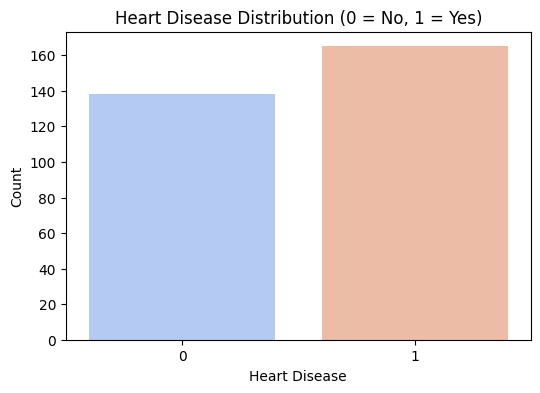

In [10]:
# Distribution of Target Variable (Heart Disease Presence)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=heart_disease["target"], palette="coolwarm")
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()


In [11]:
# heart disease Frequency according to Sex
heart_disease['sex'].value_counts()

,count
sex,
1,207
0,96


<ipython-input-12-e4fbf3f05b81>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=heart_disease["sex"], palette="coolwarm")


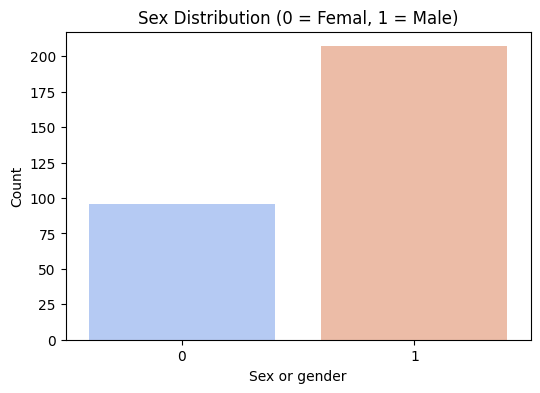

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x=heart_disease["sex"], palette="coolwarm")
plt.title("Sex Distribution (0 = Femal, 1 = Male)")
plt.xlabel("Sex or gender")
plt.ylabel("Count")
plt.show();


In [13]:
# compare target column with a sex column
pd.crosstab(heart_disease.target , heart_disease.sex)

sex,0,1
target,,
0,24,114
1,72,93


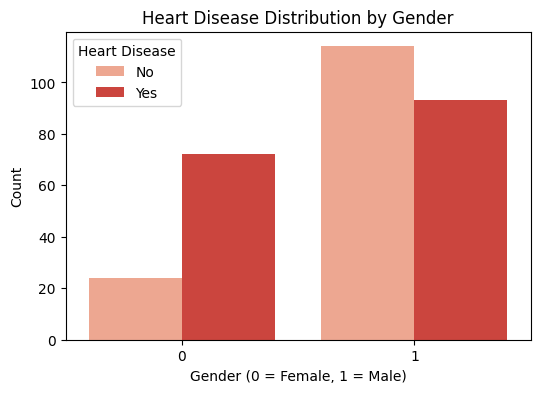

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="sex", hue="target", data=heart_disease, palette="Reds")
plt.title("Heart Disease Distribution by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No", "Yes"])
plt.show();

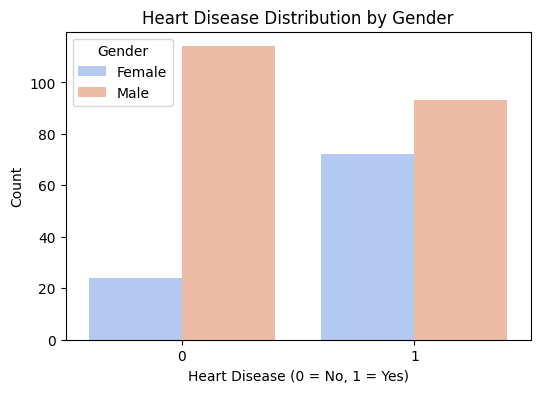

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="target", hue="sex", data=heart_disease, palette="coolwarm")
plt.title("Heart Disease Distribution by Gender")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title="Gender", labels=["Female", "Male"])
plt.show()


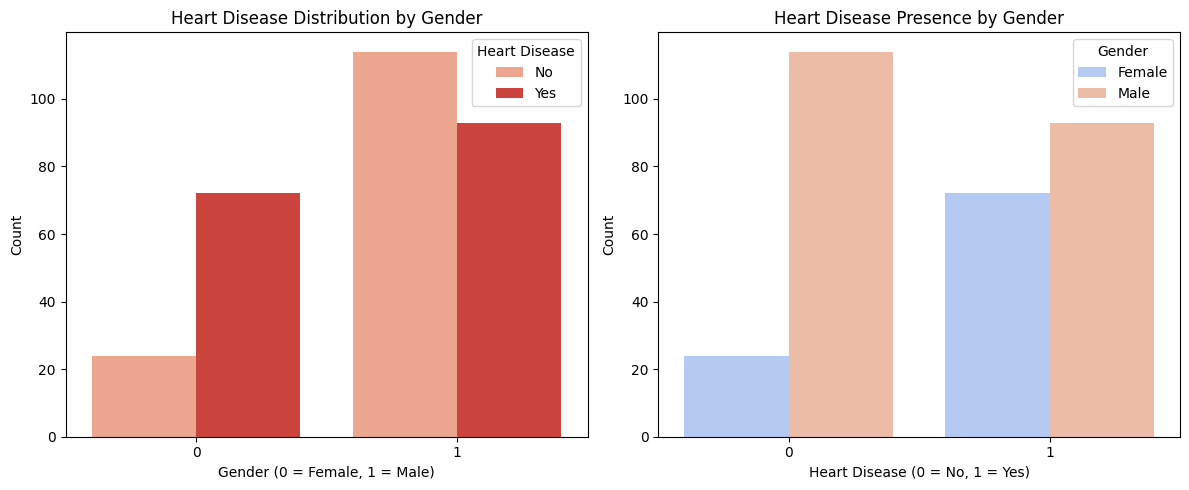

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First Plot: Gender vs. Heart Disease
sns.countplot(x="sex", hue="target", data=heart_disease, palette="Reds", ax=axes[0])
axes[0].set_title("Heart Disease Distribution by Gender")
axes[0].set_xlabel("Gender (0 = Female, 1 = Male)")
axes[0].set_ylabel("Count")
axes[0].legend(title="Heart Disease", labels=["No", "Yes"])

# Second Plot: Heart Disease vs. Gender
sns.countplot(x="target", hue="sex", data=heart_disease, palette="coolwarm", ax=axes[1])
axes[1].set_title("Heart Disease Presence by Gender")
axes[1].set_xlabel("Heart Disease (0 = No, 1 = Yes)")
axes[1].set_ylabel("Count")
axes[1].legend(title="Gender", labels=["Female", "Male"])

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


<Axes: ylabel='Frequency'>

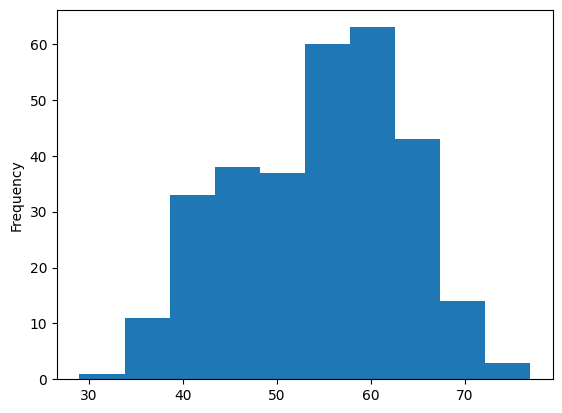

In [ ]:
heart_disease.age.plot.hist()

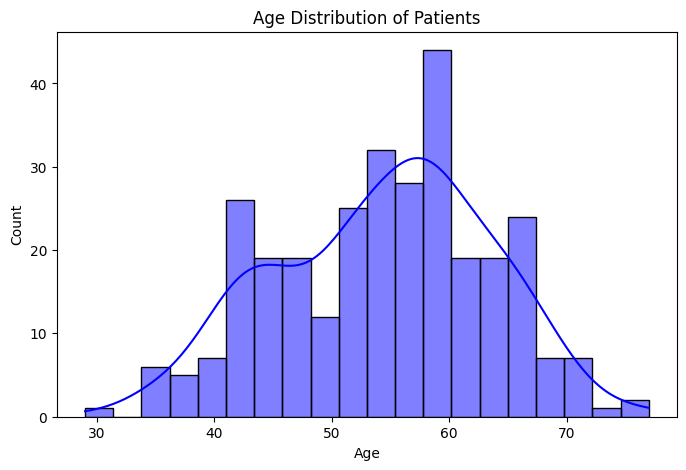

In [ ]:
#  Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(heart_disease["age"], bins=20, kde=True, color="blue")
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

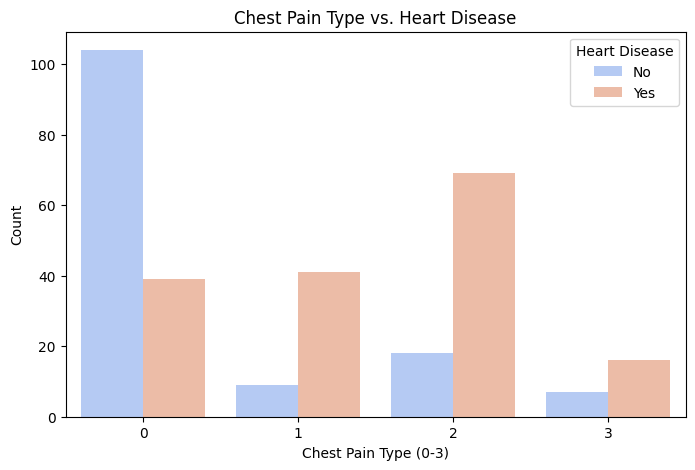

In [ ]:
# Chest Pain Type vs. Heart Disease
plt.figure(figsize=(8,5))
sns.countplot(x="cp", hue="target", data=heart_disease, palette="coolwarm")
plt.title("Chest Pain Type vs. Heart Disease")
plt.xlabel("Chest Pain Type (0-3)")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No", "Yes"])
plt.show()

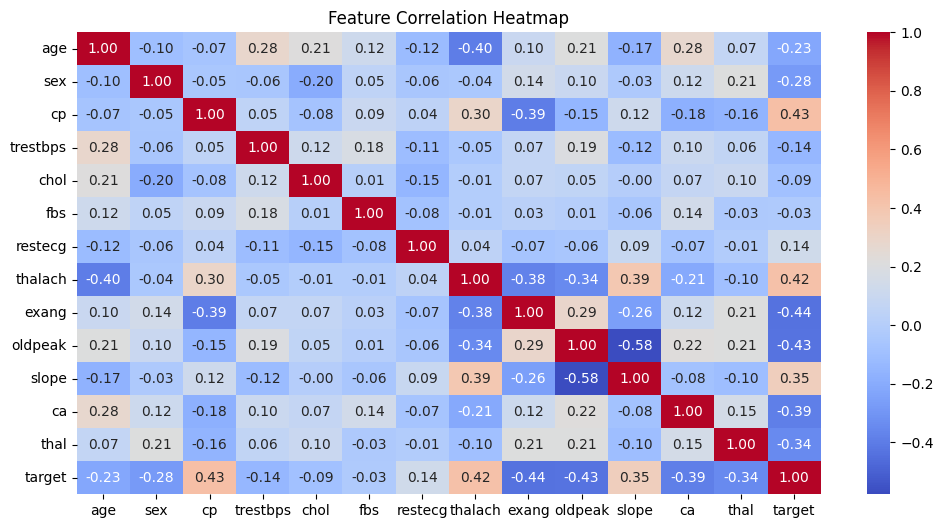

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heart_disease.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


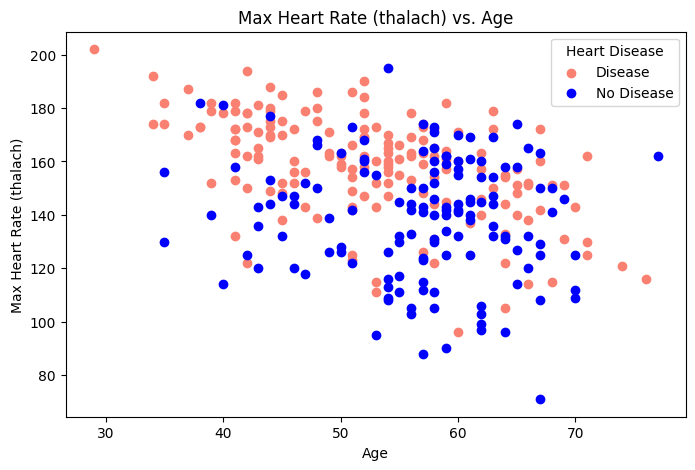

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(heart_disease.age[heart_disease.target==1],
                heart_disease.thalach[heart_disease.target==1],
                c="salmon")

plt.scatter(heart_disease.age[heart_disease.target==0],
                heart_disease.thalach[heart_disease.target==0],
                c="blue")

plt.title("Max Heart Rate (thalach) vs. Age")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate (thalach)")
plt.legend(title="Heart Disease", labels=["Disease", "No Disease"])
plt.show()

<ipython-input-13-0a96685630a5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="chol", data=heart_disease, palette="coolwarm")


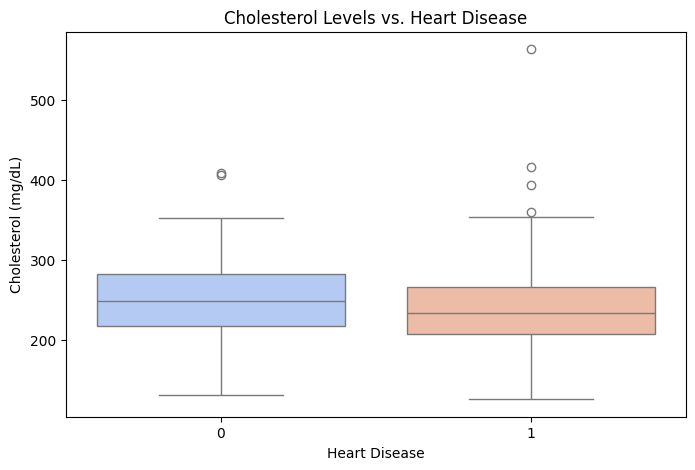

In [ ]:
# Boxplot of Cholesterol Levels by Heart Disease
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="chol", data=heart_disease, palette="coolwarm")
plt.title("Cholesterol Levels vs. Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol (mg/dL)")
plt.show()


<ipython-input-16-46005fea72dc>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="thalach", data=heart_disease, palette="coolwarm")


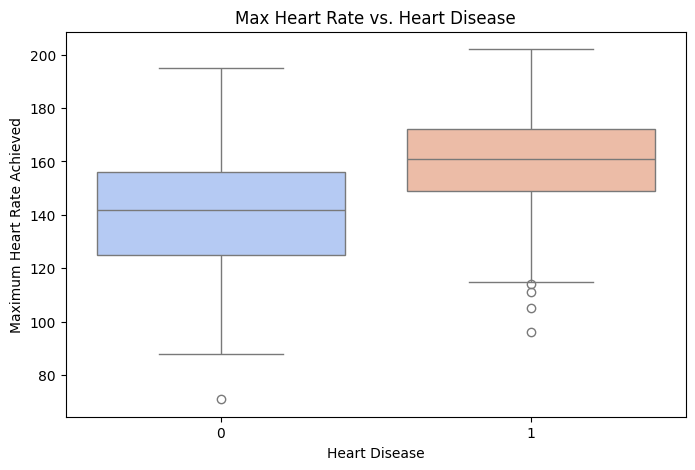

In [ ]:
# Maximum Heart Rate (thalach) vs. Heart Disease
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="thalach", data=heart_disease, palette="coolwarm")
plt.title("Max Heart Rate vs. Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate Achieved")
plt.show();


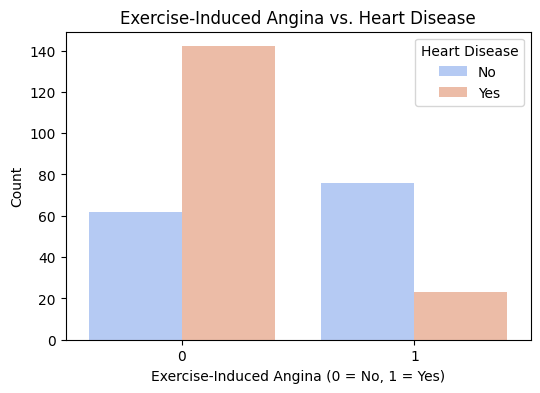

In [ ]:
#  Exercise-Induced Angina vs. Heart Disease
plt.figure(figsize=(6,4))
sns.countplot(x="exang", hue="target", data=heart_disease, palette="coolwarm")
plt.title("Exercise-Induced Angina vs. Heart Disease")
plt.xlabel("Exercise-Induced Angina (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No", "Yes"])
plt.show()


## 3️⃣ Evaluation

> if we can reah of 95% of accuracy at predicting whether or not a patient has heart disease during the proof of concept , we'll pursore the project .

## 4️⃣ Features
* `age`: Age of the patient
* `sex`: Gender (1 = male, 0 = female)
* `cp`: Chest pain type (0-3, where 3 is the most severe)
* `trestbps`: Resting blood pressure (in mm Hg)
* `chol`: Serum cholesterol (mg/dL)
* `fbs`: Fasting blood sugar (>120 mg/dL, 1 = true, 0 = false)
* `restecg`: Resting electrocardiographic results (0-2)
* `thalach`: Maximum heart rate achieved
* `exang`: Exercise-induced angina (1 = yes, 0 = no)
* `oldpeak`: ST depression induced by exercise
* `slope`: Slope of the peak exercise ST segment (0-2)
* `ca`: Number of major vessels colored by fluoroscopy (0-4)
* `thal`: Thalassemia (1 = normal, 2 = fixed defect, 3 = reversible defect)
* `target`: Heart disease (1 = present, 0 = absent)


## 5️⃣ Preparing Tools


In [15]:
# import all the tools we need

# regular EDA (exploraty data analysis ) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# %matplotlib inline  # we want our plots to appear inside the notebook


# models from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import  RandomForestClassifier


# model eveluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score , recall_score , f1_score
# from sklearn.metrics import plot_roc_curve

## 6️⃣ Modeling

In [16]:
# Split data into x and y
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

In [17]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [18]:
X.shape , y.shape

((303, 13), (303,))

In [19]:
# Split data into train and test split
np.random.seed(42)

# Split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [20]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((242, 13), (61, 13), (242,), (61,))

### 1️⃣ Choosing the right model

 We're going to try 3 different machine learning models :
1. `Logistic Regression`
2. `K-Nearest Neighbours Classifier`
3. `Random Forest Classifier`**bold text**

In [21]:
# Put models in a dictionary
models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier()}

# Create a function to fit and score models
def fit_nd_score(models ,X_train, X_test, y_train, y_test):

  # set random seed
  np.random.seed(42)
  # make a dictionary to keep model scores
  model_scores = {}

  for name ,model in models.items():
    # fit the model to the data
    model.fit(X_train, y_train)
    # evaluate the model an append its scrore to model_scores
    model_scores[name] = model.score(X_test, y_test)

  return model_scores

In [22]:
model_scores = fit_nd_score(models=models,
                            X_train=X_train,
                            X_test=X_test,
                            y_train=y_train,
                            y_test=y_test)
model_scores


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

### 2️⃣ Model comparaison

<Axes: >

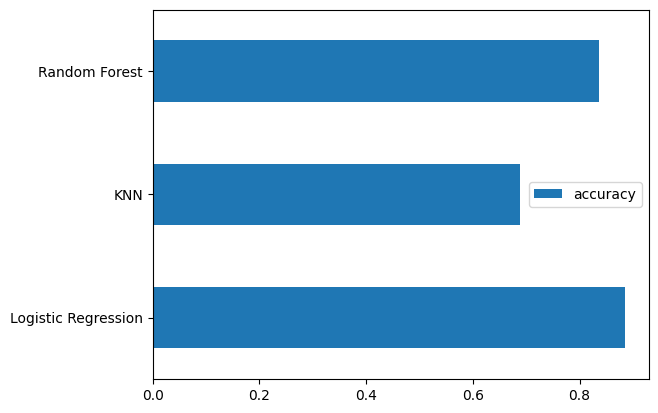

In [23]:
models_compare = pd.DataFrame(model_scores, index=["accuracy"])
models_compare.T.plot.barh()

### 3️⃣ Tuning hyperParameters


In [24]:
# use HyperParameters in KNN model
train_scores = []
test_scores = []

# create a list of different values of n-neighbors

neighbors = range(1,21)

# setup KNN instance
knn = KNeighborsClassifier()

for i in neighbors:
  knn.set_params(n_neighbors=i)

  knn.fit(X_train, y_train)

  train_scores.append(knn.score(X_train, y_train))
  test_scores.append(knn.score(X_test, y_test))



In [25]:
train_scores

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

In [26]:
test_scores

[0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6721311475409836,
 0.6885245901639344,
 0.7213114754098361,
 0.7049180327868853,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.6885245901639344,
 0.7213114754098361,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.6557377049180327]

Best score on the test set : 75.41%


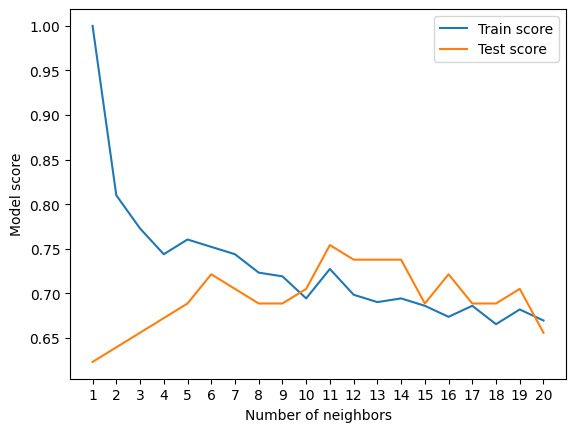

In [27]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1,21,1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

print(f"Best score on the test set : {max(test_scores)*100:.2f}%")
plt.show()

#### Tuning HyperParameters with **RandomizedSearchCV**

In [28]:
# create a HyperParameters grid for logisticRegression
log_reg_grid = {"C": np.logspace(-4,4,20),
                "solver": ["liblinear"]}

# create a Hyperparameter gri for RanomForestClassifier
rf_grid = {"n_estimators": np.arange(10,1000,50),
           "max_depth": [None,3,5,10],
           "min_samples_split": np.arange(2,20,2),
           "min_samples_leaf": np.arange(1,20,2)}



In [29]:
# Turn Logistic Regression

np.random.seed(42)

# Setup random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)

rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [30]:
# find the best params
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': 0.23357214690901212}

In [32]:
# evaluate the randomzie search LogisticRegression model
rs_log_reg.score(X_test, y_test)

0.8852459016393442

In [33]:
# turn RnadomForestClassifier
np.random.seed(42)

# Setup random search and hyperparameter grid for RandomForestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)

rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [34]:
# find the best Hyperparametwe
rs_rf.best_params_

{'n_estimators': 210,
 'min_samples_split': 4,
 'min_samples_leaf': 19,
 'max_depth': 3}

In [35]:
# evaluate the randomzie search RandomforestClassifier model
rs_rf.score(X_test, y_test)

0.8688524590163934

#### Tuning HyperParameters with **GridSearchCV**

In [36]:
# Different Hyperparameters for our LogisticRegression model

log_reg_grid = {"C": np.logspace(-4,4,30),
                "solver": ["liblinear"]}

# Setup grid hyperparameter search for LogisticRegression
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          verbose=True)

# Fit grid hyperparameter search model
gs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                         'solver': ['liblinear']},
             verbose=True)

In [37]:
# check the best HyperParameters
gs_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [38]:
# evaluate the grid search LogisticRegression model
gs_log_reg.score(X_test, y_test)

0.8852459016393442

In [29]:
# Different Hyperparameters for our RandomForestClassifier model

np.random.seed(42)

# Setup random search and hyperparameter grid for RandomForestClassifier
rs_rf = GridSearchCV(RandomForestClassifier(),
                           param_grid=rf_grid,
                           cv=5,

                           verbose=True)

rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 7200 candidates, totalling 36000 fits


KeyboardInterrupt: 

In [ ]:
# check the best HyperParameters

In [ ]:
# evaluate the grid search RandomForestClassifier model

## 6️⃣ Evaluating

###  1️⃣ Evaluating our tuned machine learning classifier, beyond accuracy

To make comparaisons and evaluate our trained model , first we need to make predictions ...

In [39]:
#  make prediction to our model
y_preds =  gs_log_reg.predict(X_test)

In [40]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [41]:
# confusion matrix
def plot_conf_matrix(y_test , y_preds):

  fig , ax =plt.subplots(figsize=(3,3))
  ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                   annot=True,
                   cbar=False)

  plt.xlabel("True label")
  plt.ylabel("Predicted label")
  plt.show()

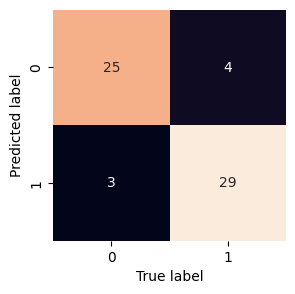

In [42]:
plot_conf_matrix(y_test, y_preds)

* `True Positive --> TP = model predict 1 when truth is 1`
* `False Positive --> FP = model predict 1 when truth is 0`
* `True Negative --> TN = model predict 0 when truth is 0`
* `False Negative --> FN = model predict 0 when truth is 1`

In [37]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### 2️⃣ Calculate Evaluation metrics using Cross-Validation

we're going to calculate precision , recall and f1-score of our model using cross-validationaand to do so we'll be using `cross_val_score()`



In [43]:
# check best hyperparameters
gs_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [44]:
# create a new classifier with best params
clf = LogisticRegression(C=0.20433597178569418 ,
                         solver = "liblinear")

In [45]:
# Cross-validated acuuracy
cv_acc = cross_val_score(clf,
                          X,
                         y,
                        cv=5,
                         scoring="accuracy")
cv_acc

array([0.81967213, 0.90163934, 0.86885246, 0.88333333, 0.75      ])

In [46]:
cv_acc = np.mean(cv_acc)
cv_acc

0.8446994535519124

In [47]:
# Cross-Validation precision
# Cross-validated acuuracy
cv_prec = cross_val_score(clf,
                          X,
                         y,
                        cv=5,
                         scoring="precision")
cv_prec

array([0.775     , 0.88571429, 0.85714286, 0.86111111, 0.725     ])

In [48]:
cv_prec = np.mean(cv_prec)
cv_prec

0.8207936507936507

In [49]:
# cross-validation recall
# Cross-validated acuuracy
cv_recall = cross_val_score(clf,
                          X,
                         y,
                        cv=5,
                         scoring="recall")
cv_recall

array([0.93939394, 0.93939394, 0.90909091, 0.93939394, 0.87878788])

In [50]:
cv_recall = np.mean(cv_recall)
cv_recall

0.9212121212121213

In [51]:
# Cross-validation f1-score
cv_f1 = cross_val_score(clf,
                          X,
                         y,
                        cv=5,
                         scoring="f1")
cv_f1

array([0.84931507, 0.91176471, 0.88235294, 0.89855072, 0.79452055])

In [52]:
cv_f1 = np.mean(cv_f1)
cv_f1

0.8673007976269721

In [53]:
evaluation= {
    "accuracy": cv_acc,
    "precision": cv_prec,
    "recall": cv_recall,
    "f1": cv_f1
}


In [54]:
evaluation

{'accuracy': 0.8446994535519124,
 'precision': 0.8207936507936507,
 'recall': 0.9212121212121213,
 'f1': 0.8673007976269721}

In [55]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



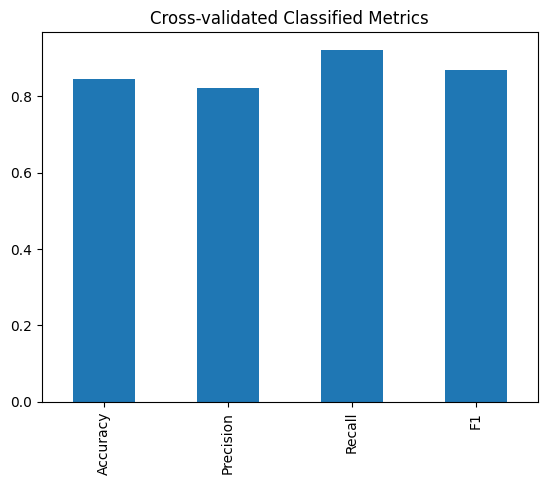

In [56]:
# visualize cross-validated metrics
cv_metrics =pd.DataFrame({
  "Accuracy": cv_acc ,
  "Precision": cv_prec,
  "Recall": cv_recall ,
  "F1": cv_f1},
    index = [0]                     )

cv_metrics.T.plot.bar(title="Cross-validated Classified Metrics", legend=False );

In [57]:
cv_metrics

,Accuracy,Precision,Recall,F1
0,0.844699,0.820794,0.921212,0.867301


## 7️⃣ Feature Importance

Features Importance is another as asking , " which features contributed mostto the outcomes of the model and how did they contributes ?"


Finding feature importance is different for each machine learnig model.One way to find feature importance is to search for"(MODEL NAME) feature importance ".


Let's find the features importance for our LogisticRegression model ...

In [63]:
# fit an instance of LogistciRegression
clf = LogisticRegression(C=0.20433597178569418 ,
                         solver = "liblinear")
clf.fit(X_train, y_train)

LogisticRegression(C=0.20433597178569418, solver='liblinear')

In [66]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [64]:
#  check coef_
clf.coef_

array([[ 0.00320769, -0.86062049,  0.66001432, -0.01155971, -0.00166496,
         0.04017236,  0.31603405,  0.02458922, -0.60470171, -0.56795456,
         0.45085392, -0.63733328, -0.67555094]])

In [70]:
clf.coef_.shape[1]

13

In [75]:
feature_dic = dict(zip(heart_disease.columns, clf.coef_[0]*100))
feature_dic

{'age': 0.32076883508599635,
 'sex': -86.06204883695241,
 'cp': 66.0014324982524,
 'trestbps': -1.155970600550047,
 'chol': -0.16649614843449206,
 'fbs': 4.01723602713081,
 'restecg': 31.603405294617176,
 'thalach': 2.458922341328129,
 'exang': -60.4701713592625,
 'oldpeak': -56.79545646616215,
 'slope': 45.08539209693025,
 'ca': -63.73332766360461,
 'thal': -67.55509369619847}

In [77]:
feature_dict= dict(zip(heart_disease.columns, [round(i, 2) for i in clf.coef_[0]*100]))
feature_dict

{'age': 0.32,
 'sex': -86.06,
 'cp': 66.0,
 'trestbps': -1.16,
 'chol': -0.17,
 'fbs': 4.02,
 'restecg': 31.6,
 'thalach': 2.46,
 'exang': -60.47,
 'oldpeak': -56.8,
 'slope': 45.09,
 'ca': -63.73,
 'thal': -67.56}

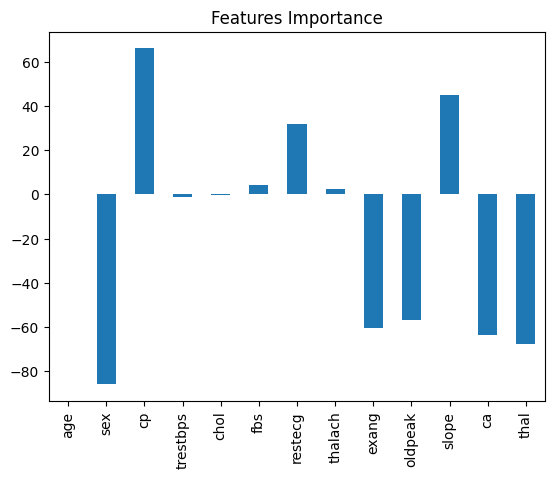

In [82]:
# Visualize feature importance
feature_d = pd.DataFrame(feature_dict, index=[0])
feature_d.T.plot.bar(title="Features Importance", legend=False)
plt.show()

In [84]:
# coefficient values with absolue values
abs_feature_dict= dict(zip(heart_disease.columns, [round(i, 2) for i in np.abs(clf.coef_[0])*100]))
abs_feature_dict

{'age': 0.32,
 'sex': 86.06,
 'cp': 66.0,
 'trestbps': 1.16,
 'chol': 0.17,
 'fbs': 4.02,
 'restecg': 31.6,
 'thalach': 2.46,
 'exang': 60.47,
 'oldpeak': 56.8,
 'slope': 45.09,
 'ca': 63.73,
 'thal': 67.56}

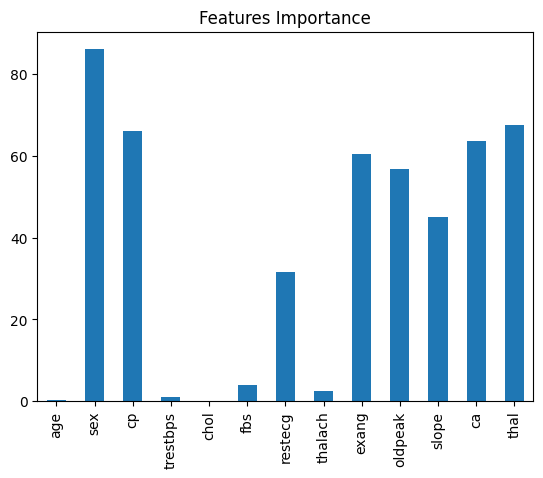

In [85]:
abs_df = pd.DataFrame(abs_feature_dict, index=[0])
abs_df.T.plot.bar(title="Features Importance", legend=False)
plt.show()

## Experimentation

if you havn't hit your evaluation metric yet ...  ask yourself ...

* `could you collect more data `
* `coud you try better model  like CatBoostor or XGBoot ?`
* `Could you improve the curent models ? (beyond what we've done so far )`
* `if your model is god enouph (you have hit your evauation metric) how would you export it and share it with others ?`